# Побудова моделі


<h2>Мета</h2>

Ознайомитись з різновидами регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Будувати регресійні моделі кількох видів
* Оцінювати якість моделі візуально
* Оцінювати якість моделі за допомогою числових мір, без використання тестової вибірки
* Виконувати прогнозування відгуку, використовуючи побудовану модель



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>

1. Скачати дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Записати дані у dataframe. В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.
2. Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.
3. Побудуйте кілька поліноміальних моделей другого порядку.
4. Побудуйте візуалізації для оцінки всіх моделей.
5. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

<a name="task1"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>



Зчитую дані з файлу у датафрейм


In [3]:
data = pd.read_csv('clean_data.csv', sep=';')

<p>З попередньої роботи знаємо, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>Population</li>
    <li>Area</li>
</ul>
Розробимо моделі, використовуючи ці ознаки як змінні-предиктори.

<p>Створюю об’єкт лінійної регресії та навчаю першу модель</p>


In [4]:
model_1 = LinearRegression()
model_1.fit(data[['Population']], data['CO2 emission'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [5]:
model_1.intercept_, model_1.coef_

(-8471.0052633374, array([0.00484817]))

Отримали кінцеву лінійну модель зі структурою:
$$
Yhat1 = a + b  X
$$

Підставляючи фактичні значення, маємо:

$$Yhat1=-8471.0052633374+0.00484817X$$

Створюю об’єкт лінійної регресії та навчаю другу модель


In [6]:
model_2 = LinearRegression()
model_2.fit(data[['Area']], data['CO2 emission'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [7]:
model_2.intercept_, model_2.coef_

(-4181.749079981935, array([0.26093456]))

Отримали кінцеву лінійну модель зі структурою:
$$
Yhat2 = a + b  X
$$

Підставляючи фактичні значення, маємо:


$$Yhat2=-4181.749079981935+0.26093456X$$

<a name="task2"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.</p>
</div>

Створюю об’єкт лінійної регресії та навчаю множинну лінійну модель із структурою
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [8]:
model_3 = LinearRegression()
model_3.fit(data[['Population', 'Area']], data['CO2 emission'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [9]:
model_3.intercept_, model_3.coef_

(-59388.318741931376, array([0.00407838, 0.12480911]))

Підставляючи фактичні значення, маємо:

$$Yhat3=-59388.318741931376+0.00407838X_{1}+0.1248091X_{2}$$

<a name="task3"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей другого порядку.</p>
</div>

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [10]:
poly = np.polyfit(data['Population'], data['CO2 emission'], 2)
model_4 = np.poly1d(poly)

Знаходжу коефіцієнти моделі


In [11]:
model_4.coef

array([-3.85132126e-13,  5.33089299e-03, -1.75947898e+04])

$$Yhat4=-3.85132126 * 10^{13}+5.33089299 * 10^{-3}X_{1}-1.75947898*10^{4}X_{1}^{2}$$

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [12]:
poly2 = np.polyfit(data['Area'], data['CO2 emission'], 2)
model_5 = np.poly1d(poly2)

Знаходжу коефіцієнти моделі


In [13]:
model_5.coef

array([-1.51966715e-08,  4.41605397e-01, -5.96322246e+04])

$$Yhat5=-1.51966715*10^{-8}+4.41605397*10^{-1}X_{2}-5.96322246*10^{4}X_{2}^{2}$$

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [14]:
poly3_features = PolynomialFeatures(2)
poly3_fit = poly3_features.fit_transform(data[['Area', 'Population']])
model_6 = LinearRegression()
model_6.fit(poly3_fit, data['CO2 emission'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Знаходжу коефіцієнти моделі


In [15]:
model_6.coef_

array([ 0.00000000e+00,  2.58694556e-02,  2.35960117e-03, -4.36709049e-09,
        1.01850351e-09, -3.17049859e-12])

$$Yhat6=0+2.58694556*10^{-2}X_{1}-2.35960117*10^{-3}X_{2}-4.36709049*10^{-9}X_{1}X_{2}+1.01850351*10^{-9}X_{1}^2-3.17049859*10^{-12}X_{2}^2$$

<a name="task4"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте візуалізації для оцінки всіх моделей.</p>
</div>

Для простої лінійної регресії чудовим способом візуалізації відповідності моделі є використання графіків регресії. Цей графік покаже комбінацію розсіяних точок даних (діаграма розсіювання, scatterplot) та підігнану лінію лінійної регресії, що проходить через дані.

Таким способом візуалізую перші моделі.


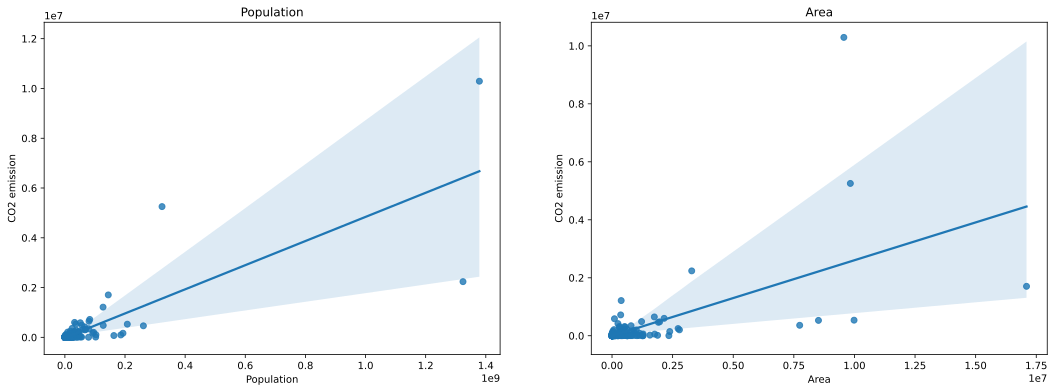

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.set_title('Population')
ax2.set_title('Area')

sns.regplot(x=data['Population'], y=data['CO2 emission'], ax=ax1)
sns.regplot(x=data['Area'], y=data['CO2 emission'], ax=ax2);

З даних графіків, можемо зробити висновок про наявність залежності між змінними з позитивним коефіцієнтом кореляції.

Для візуалізації дисперсії даних використаю діаграми залишків - по ній зможу прийняти рішення про необхідність ускладнення моделі.


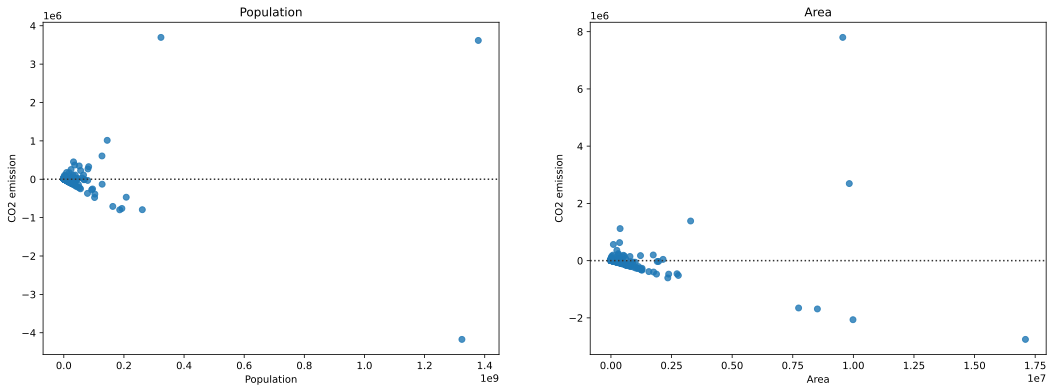

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.set_title('Population')
ax2.set_title('Area')

sns.residplot(x=data['Population'], y=data['CO2 emission'], ax=ax1)
sns.residplot(x=data['Area'], y=data['CO2 emission'], ax=ax2);

Можемо побачити, що зі збільшенням значень предикторів, модель починає сильніше помилятись. Це може бути пов'язано з недостатньо великою кількістю даних з великим значенням предиктора.

Для візуалізації моделі множинної лінійної регресії використаю діаграму розподілу.


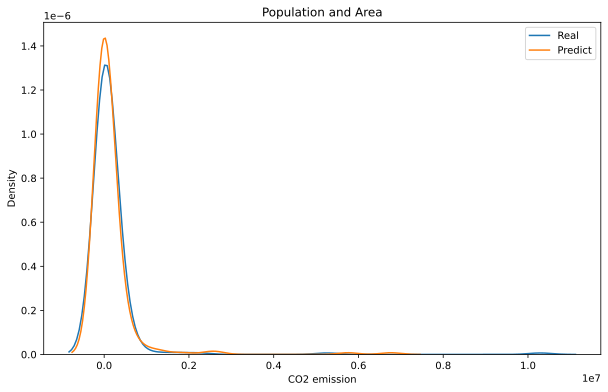

In [18]:
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_title('Population and Area')

sns.kdeplot(data['CO2 emission'], ax=ax, label='Real')
sns.kdeplot(model_3.predict(data[['Population', 'Area']]), ax=ax, label='Predict')
ax.legend();

Можемо побачити, що розподіли двох діаграм майже ідентичні, що свідчить про непогано навчену модель

Для візуалізації поліноміальних моделей з одним предиктором використаю функцію <code>poly1d</code>. Зручно розміщувати всі моделі на одному графіку для обрання найкращої.


In [19]:
def plot_polly(model, x, y, axis, c='r'):
    x_new = np.linspace(x.min(), x.max(), 1000)
    y_new = model(x_new)

    sns.scatterplot(x=x, y=y, markers='.', c=c, ax=axis)
    sns.lineplot(x=x_new, y=y_new, c=c, ax=axis)

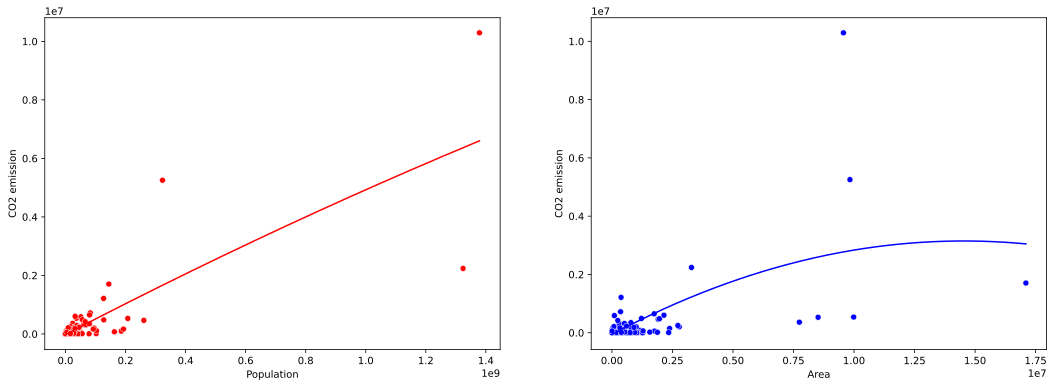

In [20]:
poly_x = np.linspace(0, 1e7, 1000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
plot_polly(model_4, data['Population'], data['CO2 emission'], ax1)
plot_polly(model_5, data['Area'], data['CO2 emission'], ax2, c='b')

Нанесення цих двох моделей на один графік не має сенсу, оскільки вони використовують різні предиктори.

Для візуалізації поліноміальних моделей з кількома предикторами використаю діаграму розподілу або діаграму залишків


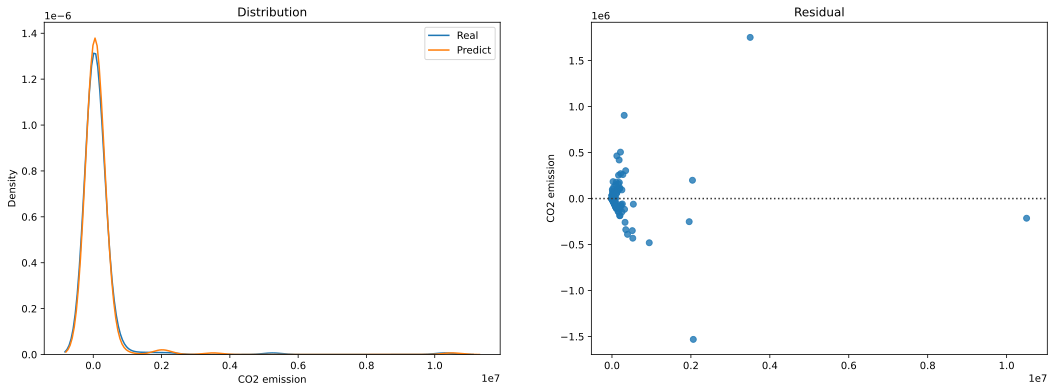

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(data['CO2 emission'], ax=ax1, label='Real')
sns.kdeplot(model_6.predict(poly3_fit), ax=ax1, label='Predict')
ax1.set_title('Distribution')
ax1.legend()

sns.residplot(x=model_6.predict(poly3_fit), y=data['CO2 emission'], ax=ax2)
ax2.set_title('Residual');

<a name="task5"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.</p>
</div>

Значення R^2 отримую безпосередньо з моделі <code>.score(X, Y)</code>, а для розрахунку MSE спочатку формую прогнозовані значення <code>.predict(X)</code> і порівнюю їх з фактичними


In [22]:
results = pd.DataFrame({'R^2': [], 'MSE': []})

Модель 1:
$$
Yhat1 = a + b  X
$$


In [23]:
score_1 = model_1.score(data[['Population']], data['CO2 emission'])
predicted_1 = model_1.predict(data[['Population']])
mse_1 = mean_squared_error(data['CO2 emission'], predicted_1)
results.loc['model_1'] = [score_1, mse_1]
score_1, mse_1

(0.6465782702522851, 231216218754.84842)

Модель 2:
$$
Yhat2 = a + b  X
$$

In [24]:
score_2 = model_2.score(data[['Area']], data['CO2 emission'])
predicted_2 = model_2.predict(data[['Area']])
mse_2 = mean_squared_error(data['CO2 emission'], predicted_2)
results.loc['model_2'] = [score_2, mse_2]
score_2, mse_2

(0.34610141870294964, 427794741213.53564)

Модель 3:
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [25]:
score_3 = model_3.score(data[['Population', 'Area']], data['CO2 emission'])
predicted_3 = model_3.predict(data[['Population', 'Area']])
mse_3 = mean_squared_error(data['CO2 emission'], predicted_3)
results.loc['model_3'] = [score_3, mse_3]
score_3, mse_3

(0.7094605407170275, 190077263281.0122)

Модель 4:
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [26]:
predicted_4 = model_4(data['Population'])
score_4 = r2_score(data['CO2 emission'], predicted_4)
mse_4 = mean_squared_error(data['CO2 emission'], predicted_4)
results.loc['model_4'] = [score_4, mse_4]
score_4, mse_4

(0.6470952715577707, 230877985203.0206)

Модель 5:
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [27]:
predicted_5 = model_5(data['Area'])
score_5 = r2_score(data['CO2 emission'], predicted_5)
mse_5 = mean_squared_error(data['CO2 emission'], predicted_5)
results.loc['model_5'] = [score_5, mse_5]
score_5, mse_5

(0.3743860535201925, 409290315025.6693)

Модель 6:
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [28]:
score_6 = model_6.score(poly3_features.transform(data[['Area', 'Population']]), data['CO2 emission'])
predicted_6 = model_6.predict(poly3_features.transform(data[['Area', 'Population']]))
mse_6 = mean_squared_error(data['CO2 emission'], predicted_6)
results.loc['model_6'] = [score_6, mse_6]
score_6, mse_6

(0.9380417225821578, 40534459030.981606)

<h4>Результати</h4>

In [29]:
results

,R^2,MSE
model_1,0.646578,2.312162e+11
model_2,0.346101,4.277947e+11
model_3,0.709461,1.900773e+11
model_4,0.647095,2.308780e+11
model_5,0.374386,4.092903e+11
model_6,0.938042,4.053446e+10


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>поліноміальна модель з кількома предикторами є найкращою моделлю</b> для прогнозування 'CO2 emission' на основі нашого набору даних. </p>
<p>Ця модель є найскладнішою серед створених 6-ти, проте й показує найкращі результати. Значення коефіцієнту детермінації становить майже 94%, а середня квадратична помилка 4.05 * 10^10.</p>


<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте та оцініть кілька поліноміальних моделей різних порядків.</p>
</div>

1. Побудуйте кілька поліноміальних моделей різних порядків.
2. Побудуйте візуалізації для оцінки всіх моделей (зручно розміщувати всі моделі на одному графіку для обрання найкращої).
3. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі (теж доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі).
4. Оберіть найкращу модель, висновок обгрунтуйте.


Побудуємо моделі порядків від 2 до 9

In [30]:
x_poly = data['Population']
y_poly = data['CO2 emission']

def build_model(x, y, power):
    poly = np.polyfit(x, y, power)
    model = np.poly1d(poly)
    return model

models = pd.Series(dtype=object)
for i in range(2, 10):
    models.loc[i] = build_model(x_poly, y_poly, i)

Побудуємо візуалізації для всіх моделей з різним наближенням

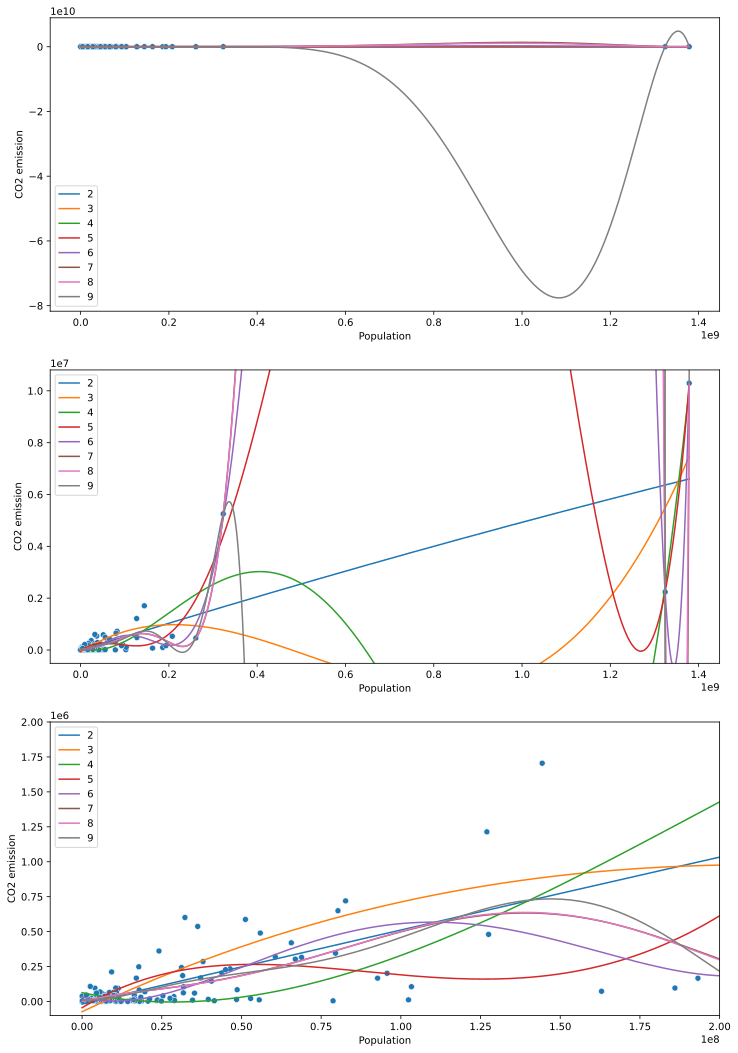

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

sns.scatterplot(x=x_poly, y=y_poly, ax=ax1)
sns.scatterplot(x=x_poly, y=y_poly, ax=ax2)
sns.scatterplot(x=x_poly, y=y_poly, ax=ax3)
limits = (ax1.get_xlim(), ax1.get_ylim())

x_linspace = np.linspace(0, x_poly.max(), 1000)
for i, model in zip(models.index, models):
    sns.lineplot(x=x_linspace, y=model(x_linspace), ax=ax1, label=f'{i}')
    sns.lineplot(x=x_linspace, y=model(x_linspace), ax=ax2, label=f'{i}')
    sns.lineplot(x=x_linspace, y=model(x_linspace), ax=ax3, label=f'{i}')

ax2.set_xlim(limits[0])
ax2.set_ylim(limits[1])
ax3.set_xlim(-1e7, 2e8)
ax3.set_ylim(-1e5, 2e6)
plt.legend();

Знайдемо значення R^2 та MSE для оцінки якості кожної моделі

In [41]:
poly_results = pd.DataFrame({'R^2': [], 'MSE': []})
poly_results.index.names = ['power']

for i, model in zip(models.index, models):
    predicted_p = model(x_poly)
    score_p = r2_score(y_poly, predicted_p)
    mse_p = mean_squared_error(y_poly, predicted_p)
    poly_results.loc[f'{i}'] = [score_p, mse_p]

In [42]:
poly_results

,R^2,MSE
power,,
2,0.647095,2.308780e+11
3,0.672927,2.139782e+11
4,0.871118,8.431771e+10
5,0.935686,4.207537e+10
6,0.965499,2.257122e+10
7,0.971124,1.889102e+10
8,0.971127,1.888931e+10
9,0.971848,1.841757e+10


Отже, можемо побачити результати всіх моделей. Моделі порядків менше 4-го показують набагато гірші результати, ніж починаючи з 4-го. З 4-го по 6-й порядок моделі йде приріст по 3-6% у оцінці R^2 і зменшується середня квадратична помилка відповідно. З 6-го по 9-й порядок приріст R^2 стає набагато меншим (<0.5%), і значення MSE змінюється не так сильно.<br><br>
Вибір фінальної моджелі залежить також від поставлених вимог, якщо стоїть завдання досягти 90%+ значення R^2, то доцільніше буде обрати 5-й або 6-й порядок, бо не буде сенсу витрачати більше обчислювальних потужностей, якщо цього не вимагається. У разі вимоги найбільшого значення R^2, варто дивитись на моделі більших порядків (у 9-го найбільше значення), які вимагають вже більше потужностей.<br><br>
Якщо просто необхідно обрати модель серед цих для використання, то варто обрати між 6-7 порядками, які показують вже пристойний результат (97.1%) і після яких збільшення показника R^2 не є настільки суттєвим, щоб витрачати обчислювальні потужності на обрахунок більших степенів. Особисто я б зупинився на моделі 7-го порядку.

<h2>Виконав студент групи ІП-42<br>  Губін Микита</h2>

#### Нове
Графіки залежності MSE та R^2 від степеня поліному

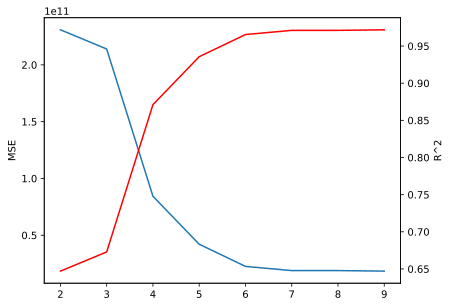

In [44]:
ax1 = plt.gca()
ax2 = ax1.twinx()
sns.lineplot(x=range(2, 10), y=poly_results['MSE'], ax=ax1)
sns.lineplot(x=range(2, 10), y=poly_results['R^2'], ax=ax2, c='r');